### 필수과제4
- 필수과제3번에서 가장 많은 범죄가 있는 지역 5개와 가장 적은 범죄가 있는 지역 5개를 seasonal_decompose 하여서 
- 차이를 분석해 주세요 (어떤 트렌드가 있는지?, 실제 범죄가 많은 곳과 적은 곳의 차이가 존재하는지?)

Decomposing Top 5 Crime Regions:


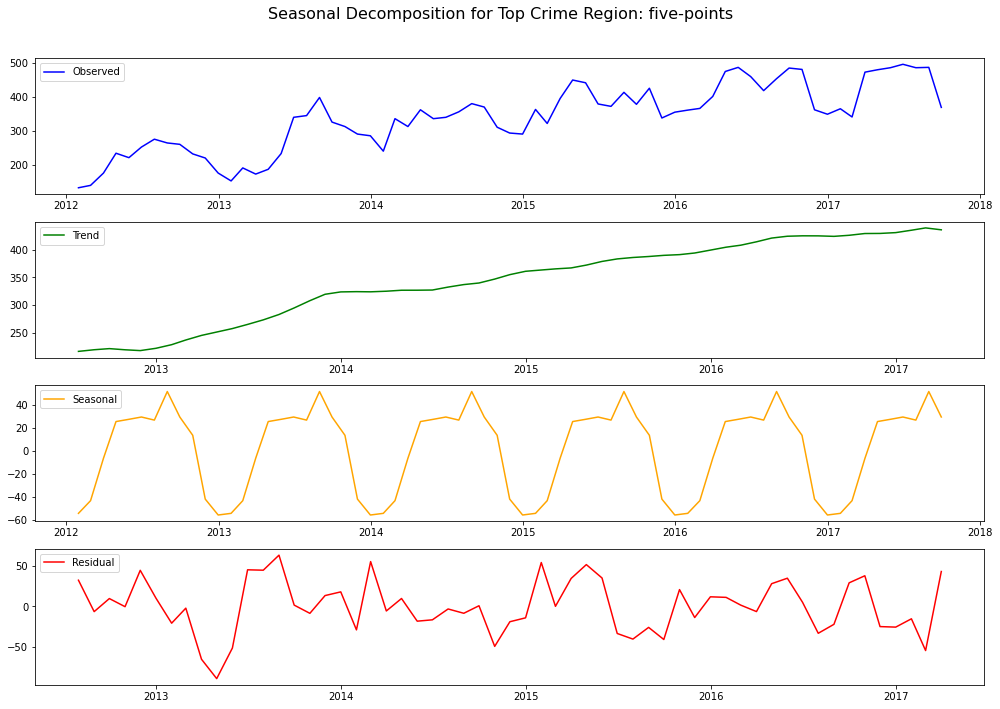

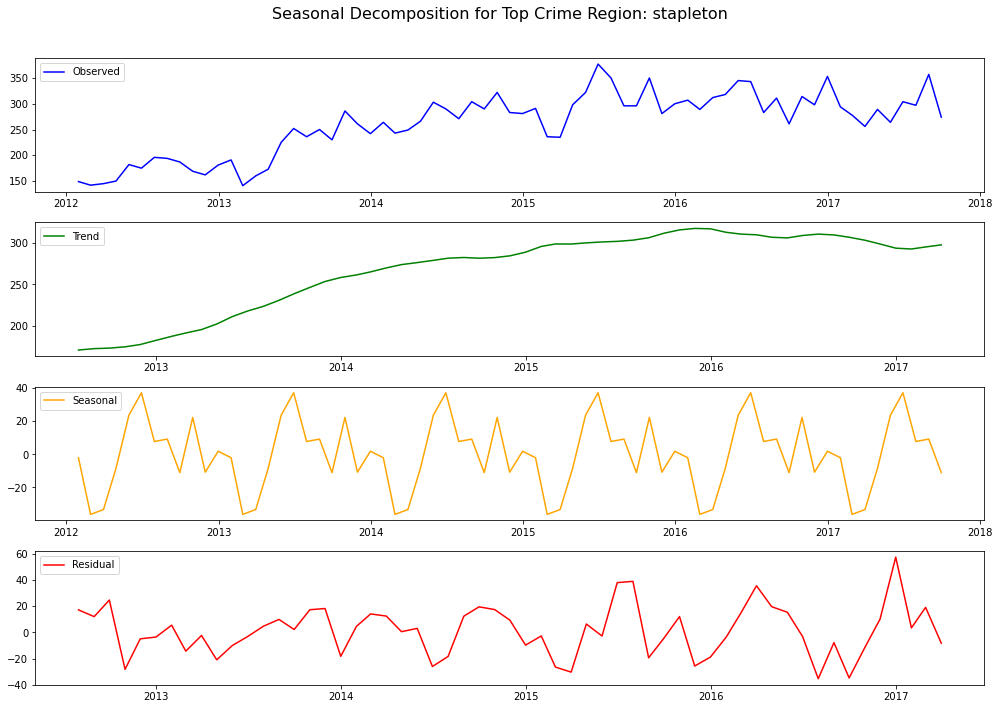

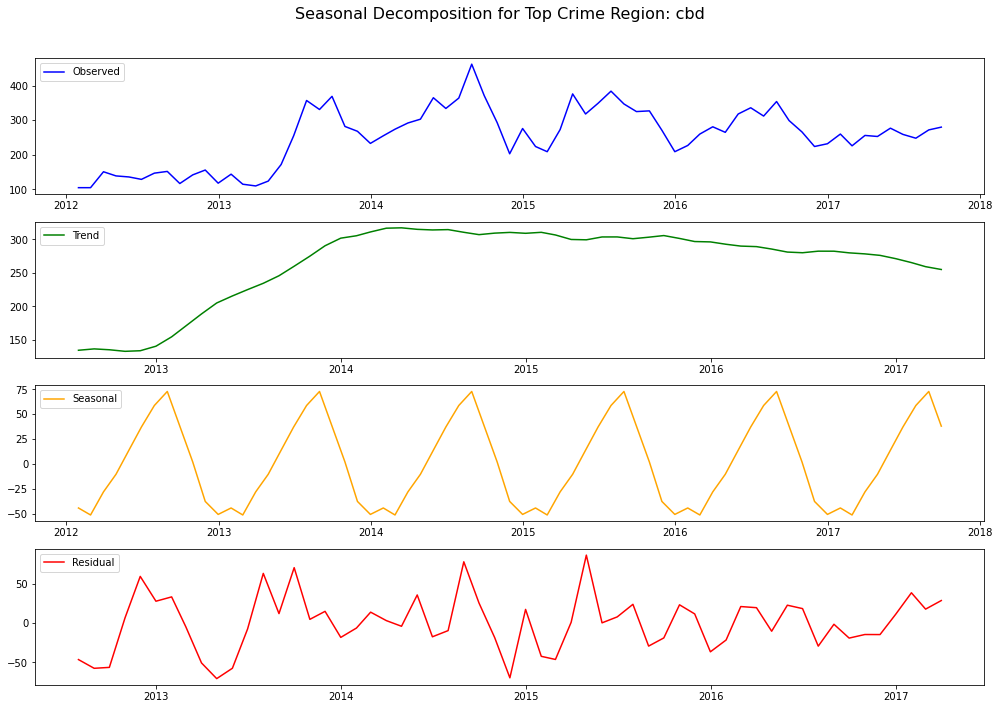

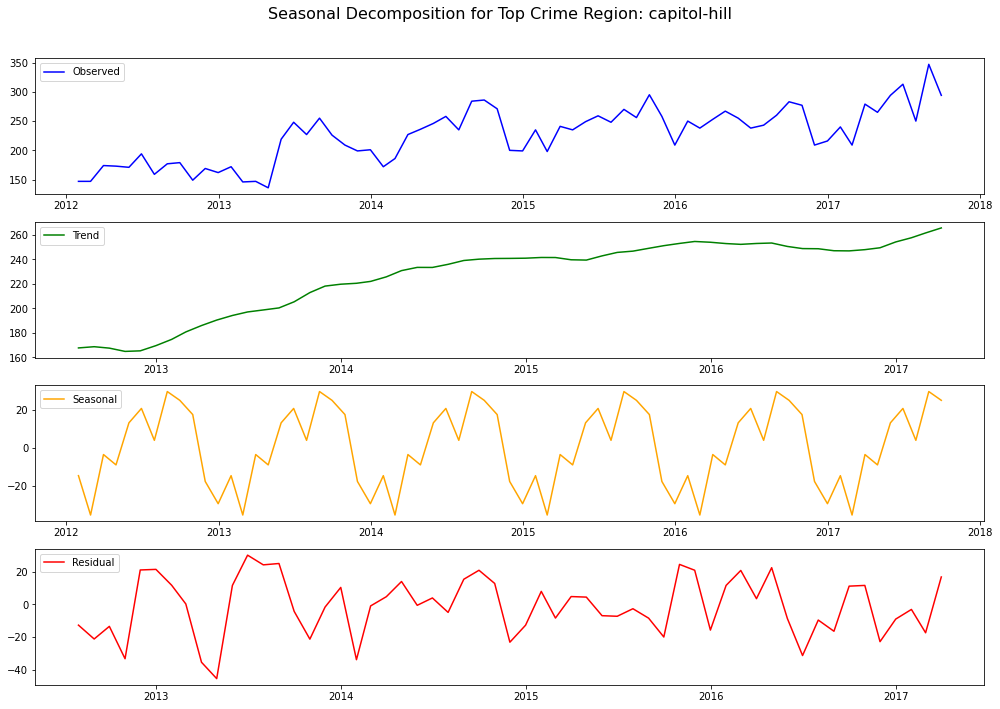

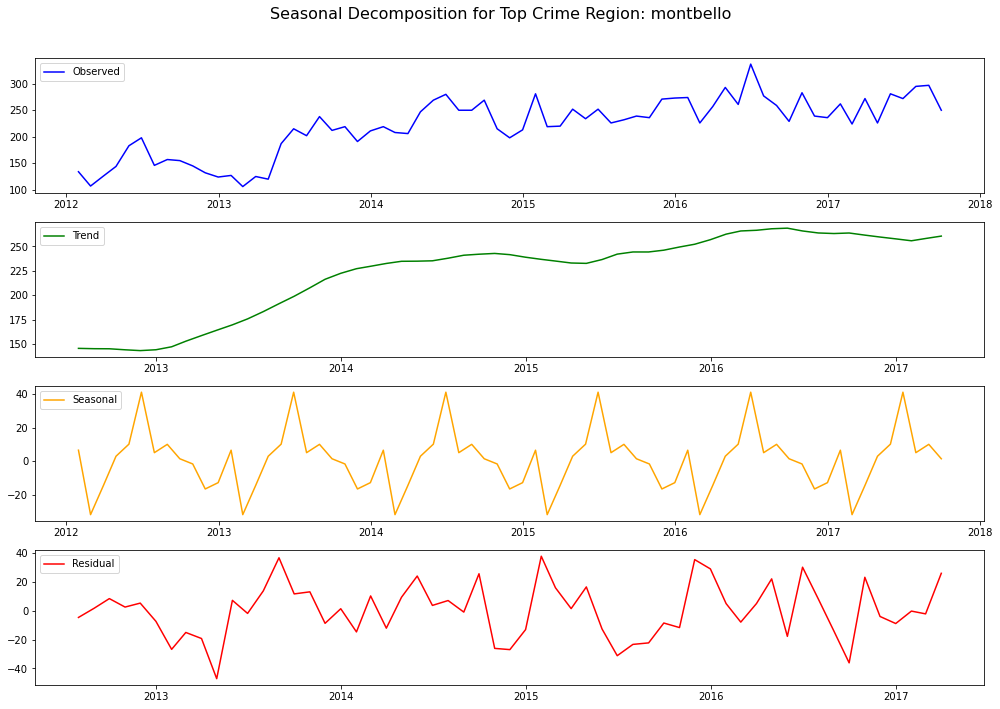


Decomposing Bottom 5 Crime Regions:


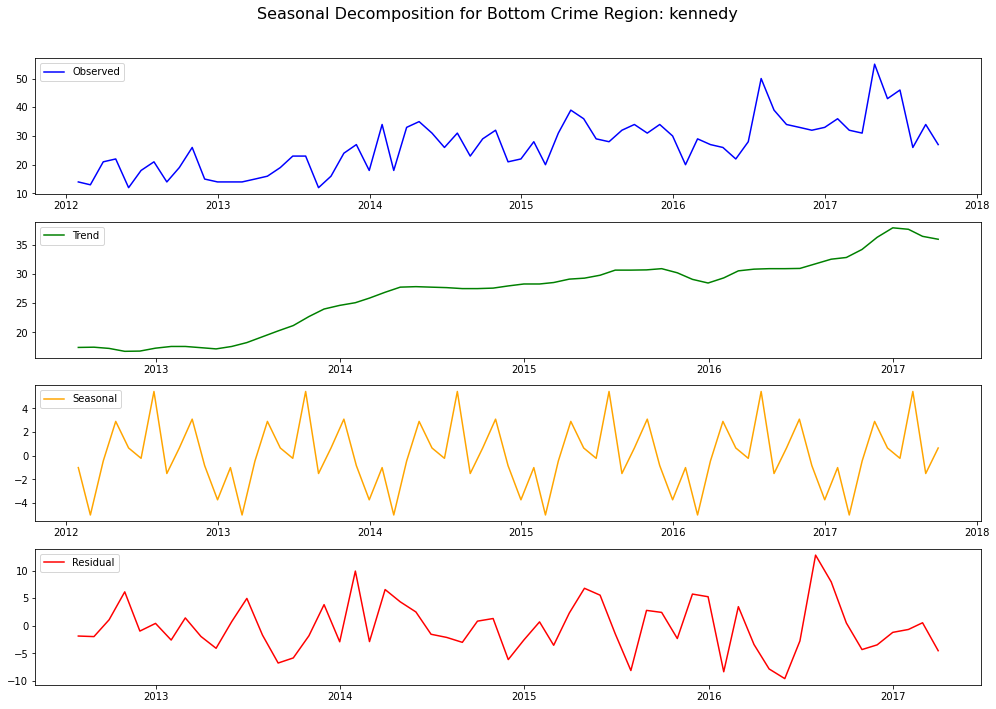

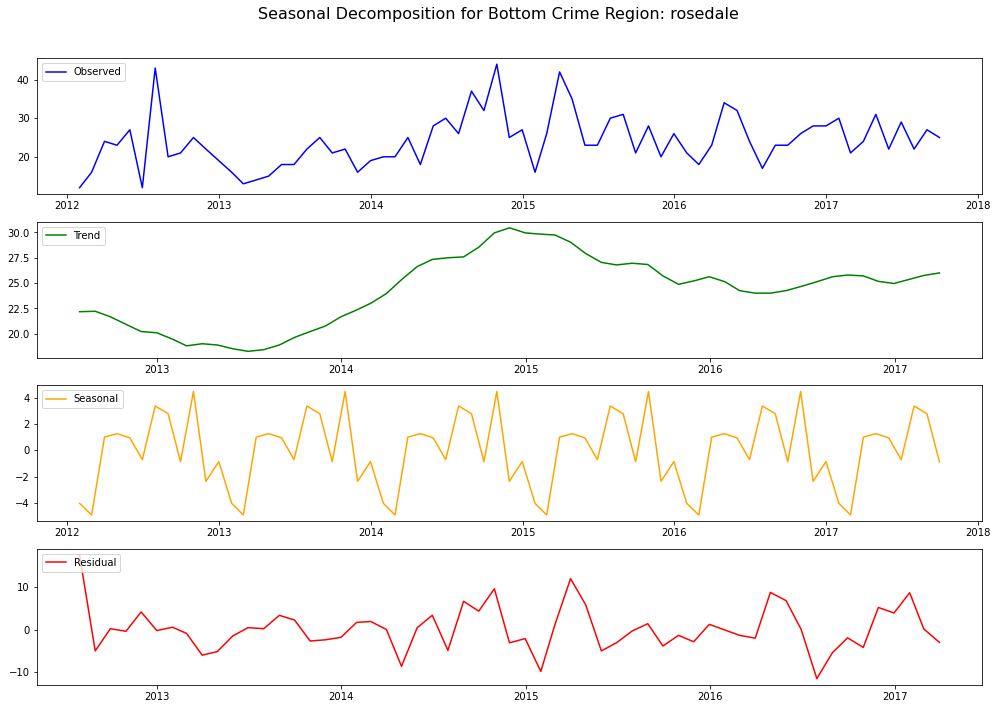

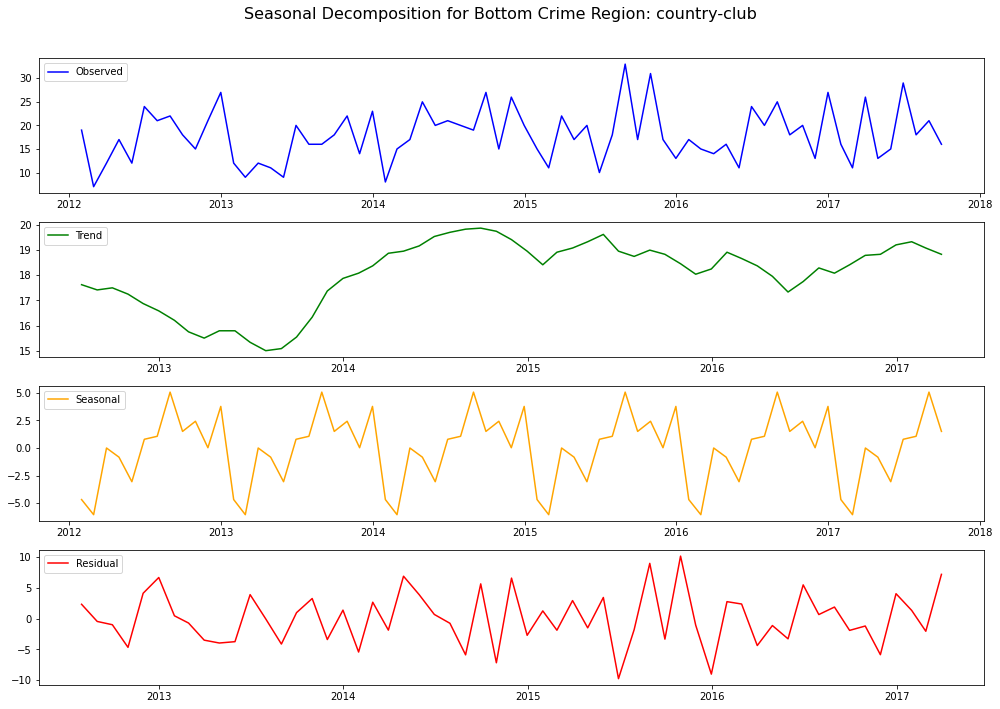

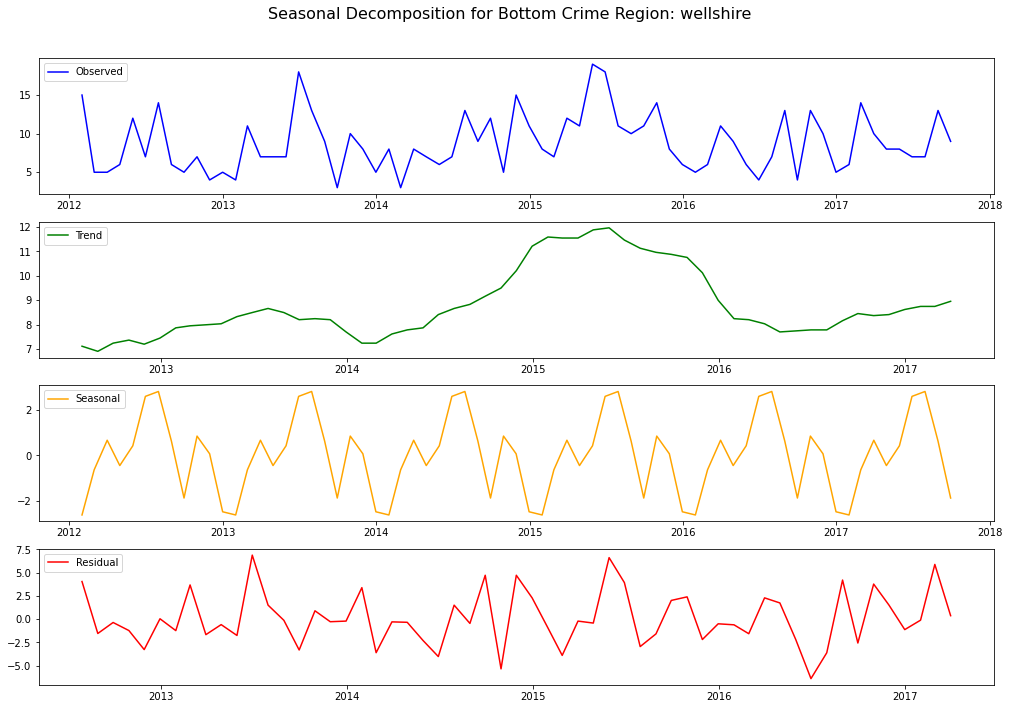

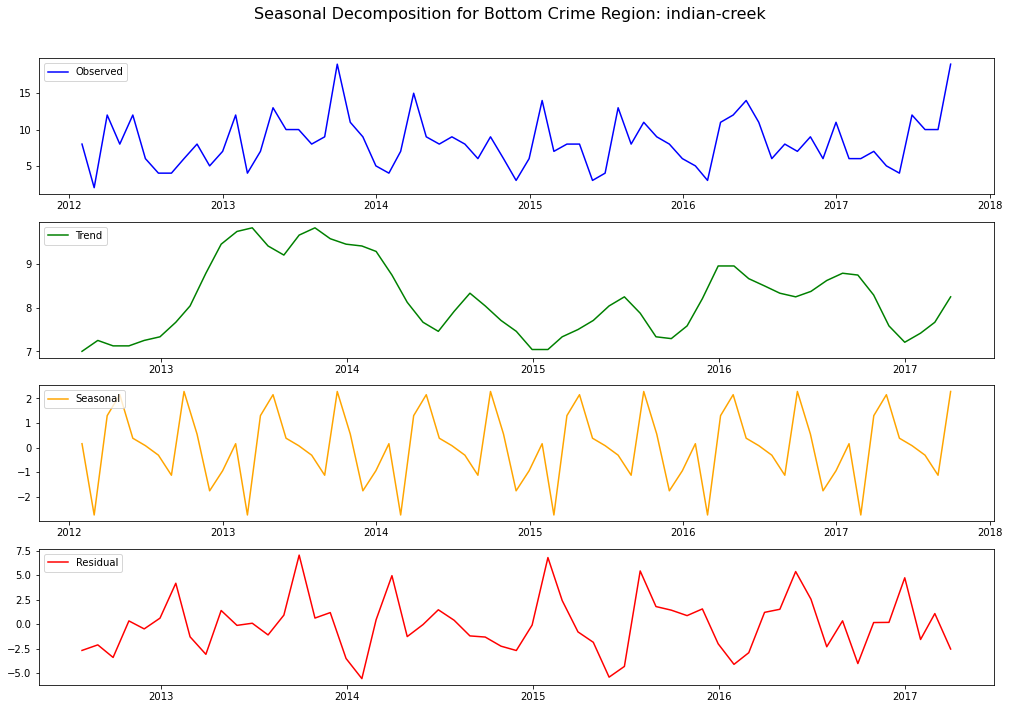

In [7]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Load and preprocess the dataset
df = pd.read_csv(r'C:\Users\user\BDA_Data\Dataset\crime.csv')
df['REPORTED_DATE'] = pd.to_datetime(df['REPORTED_DATE'])
df.set_index('REPORTED_DATE', inplace=True)

# Aggregate crimes by region
region_crime_counts = df['NEIGHBORHOOD_ID'].value_counts()

# Get the 5 regions with the most and least crimes
top_5_regions = region_crime_counts.head(5).index
bottom_5_regions = region_crime_counts.tail(5).index

# Function to perform seasonal decomposition and plot
def decompose_and_plot(region, title):
    # Filter data for the region and resample monthly
    region_data = df[df['NEIGHBORHOOD_ID'] == region].resample('M').size()

    # Ensure sufficient data for decomposition (minimum 24 months)
    if len(region_data) < 24:
        print(f"Not enough data for region: {region}")
        return None

    # Perform seasonal decomposition
    decomposition = seasonal_decompose(region_data, model='additive', period=12)

    # Plot the decomposition
    plt.figure(figsize=(14, 10))
    plt.suptitle(f"Seasonal Decomposition for {title}", fontsize=16)
    plt.subplot(4, 1, 1)
    plt.plot(decomposition.observed, label='Observed', color='blue')
    plt.legend(loc='upper left')
    plt.subplot(4, 1, 2)
    plt.plot(decomposition.trend, label='Trend', color='green')
    plt.legend(loc='upper left')
    plt.subplot(4, 1, 3)
    plt.plot(decomposition.seasonal, label='Seasonal', color='orange')
    plt.legend(loc='upper left')
    plt.subplot(4, 1, 4)
    plt.plot(decomposition.resid, label='Residual', color='red')
    plt.legend(loc='upper left')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return decomposition

# Decompose top 5 regions with the most crimes
print("Decomposing Top 5 Crime Regions:")
top_decompositions = {}
for region in top_5_regions:
    top_decompositions[region] = decompose_and_plot(region, f"Top Crime Region: {region}")

# Decompose bottom 5 regions with the least crimes
print("\nDecomposing Bottom 5 Crime Regions:")
bottom_decompositions = {}
for region in bottom_5_regions:
    bottom_decompositions[region] = decompose_and_plot(region, f"Bottom Crime Region: {region}")


- 추세 안정성: 범죄율이 높은 지역에서는 변동폭이 더 큽니다.
- 계절 영향: 범죄율이 높은 지역은 계절의 영향을 더 많이 받습니다.
- 불규칙성: 범죄율이 높은 지역에서는 예상치 못한 변화가 더 많이 발생합니다.